<a href="https://colab.research.google.com/github/mivanf/ProjectAkhirDataSains/blob/main/ARModel_DataScienceProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install statsmodels --upgrade

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

In [20]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/HargaEmasSetiapHari2026HapusHariMinggu.csv',index_col=0,parse_dates=True)
X=df.dropna().values
print('Shape of data \t',df.shape)
print('Original Dataset:\n',df.head())
print('After Extracting only price:\n',X)

Shape of data 	 (409, 1)
Original Dataset:
               Harga
Tanggal            
2025-01-01  1433000
2025-01-02  1442000
2025-01-03  1455000
2025-01-04  1451000
2025-01-06  1451000
After Extracting only price:
 [[1433000]
 [1442000]
 [1455000]
 [1451000]
 [1451000]
 [1446000]
 [1453000]
 [1458000]
 [1467000]
 [1478000]
 [1478000]
 [1469000]
 [1473000]
 [1484000]
 [1496000]
 [1489000]
 [1478000]
 [1493000]
 [1504000]
 [1505000]
 [1506000]
 [1509000]
 [1507000]
 [1498000]
 [1509000]
 [1508000]
 [1517000]
 [1521000]
 [1518000]
 [1538000]
 [1551000]
 [1558000]
 [1550000]
 [1550000]
 [1555000]
 [1588000]
 [1579000]
 [1588000]
 [1597000]
 [1579000]
 [1572000]
 [1580000]
 [1591000]
 [1604000]
 [1603000]
 [1600000]
 [1601000]
 [1603000]
 [1593000]
 [1591000]
 [1580000]
 [1574000]
 [1581000]
 [1602000]
 [1607000]
 [1604000]
 [1593000]
 [1593000]
 [1596000]
 [1585000]
 [1604000]
 [1614000]
 [1637000]
 [1634000]
 [1636000]
 [1640000]
 [1652000]
 [1666000]
 [1668000]
 [1658000]
 [1659000]
 [165

<Axes: xlabel='Tanggal'>

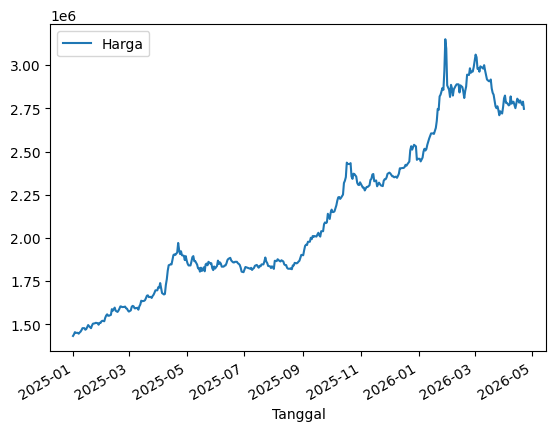

In [21]:
df.plot()

In [22]:
# Uji Augmented Dickey-Fuller (ADF) pada data asli
dftest = adfuller(df['Harga'], autolag = 'AIC')

print("1. ADF : ", dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation : ", dftest[3])
print("5. Critical values :")
for key, val in dftest[4].items():
  print("\t",key, ": ",val)

1. ADF :  -0.7419038746394114
2. P-Value :  0.83559495014607
3. Num Of Lags :  2
4. Num Of Observations Used For ADF Regression and Critical Values Calculation :  406
5. Critical values :
	 1% :  -3.4465596717208813
	 5% :  -2.8686852499495843
	 10% :  -2.570576203741901


In [23]:
# Karena p-value > 0.05 lakukan differencing
gold_prices = df['Harga']
gold_prices_diff = gold_prices.diff().dropna().values

print('Shape of data \t',gold_prices_diff.shape)
print('Gold Price:\n',gold_prices_diff)

dftest_diff = adfuller(gold_prices_diff, autolag = 'AIC')

print("1. ADF : ", dftest_diff[0])
print("2. P-Value : ", dftest_diff[1])
print("3. Num Of Lags : ", dftest_diff[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation : ", dftest_diff[3])
print("5. Critical values :")
for key, val in dftest_diff[4].items():
  print("\t",key, ": ",val)

Shape of data 	 (408,)
Gold Price:
 [   9000.   13000.   -4000.       0.   -5000.    7000.    5000.    9000.
   11000.       0.   -9000.    4000.   11000.   12000.   -7000.  -11000.
   15000.   11000.    1000.    1000.    3000.   -2000.   -9000.   11000.
   -1000.    9000.    4000.   -3000.   20000.   13000.    7000.   -8000.
       0.    5000.   33000.   -9000.    9000.    9000.  -18000.   -7000.
    8000.   11000.   13000.   -1000.   -3000.    1000.    2000.  -10000.
   -2000.  -11000.   -6000.    7000.   21000.    5000.   -3000.  -11000.
       0.    3000.  -11000.   19000.   10000.   23000.   -3000.    2000.
    4000.   12000.   14000.    2000.  -10000.    1000.   -6000.   11000.
    7000.   12000.   14000.       0.   18000.   -3000.   27000.  -28000.
  -30000.   -8000.    3000.   52000.   33000.   50000.   31000.    5000.
       0.   28000.   26000.    4000.   -3000.   14000.   55000.  -41000.
  -23000.   16000.  -23000.   -3000.  -25000.   23000.  -26000.  -18000.
  -10000.      

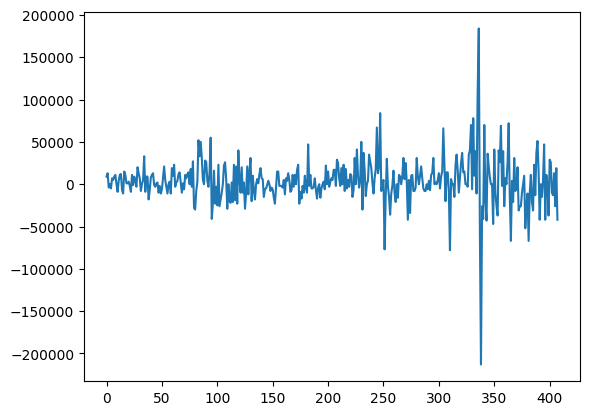

In [24]:
pyplot.plot(gold_prices_diff)

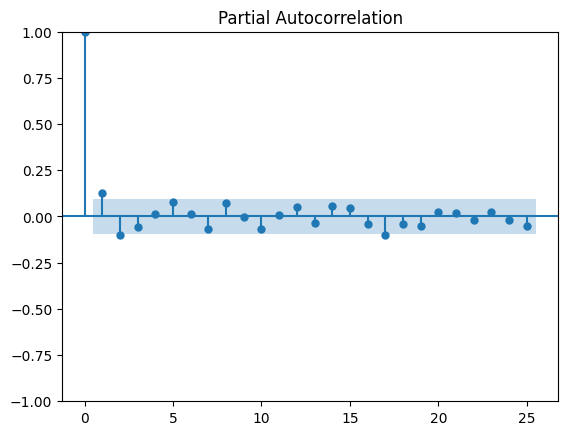

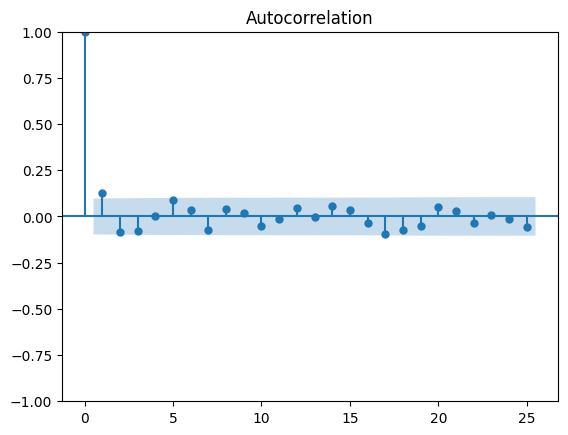

In [25]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf
pacf=plot_pacf(gold_prices_diff,lags=25)
acf=plot_acf(gold_prices_diff,lags=25)

In [26]:
train_diff = gold_prices_diff[:len(gold_prices_diff)-5]
test_diff = gold_prices_diff[len(gold_prices_diff)-5:]

In [27]:
model_diff = AutoReg(train_diff, lags=14).fit()

In [28]:
print(model_diff.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  403
Model:                    AutoReg(14)   Log Likelihood               -4506.535
Method:               Conditional MLE   S.D. of innovations          26003.437
Date:                Wed, 22 Apr 2026   AIC                           9045.070
Time:                        04:06:30   BIC                           9108.487
Sample:                            14   HQIC                          9070.211
                                  403                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2952.0699   1450.416      2.035      0.042     109.307    5794.832
y.L1           0.1530      0.051      3.021      0.003       0.054       0.252
y.L2          -0.0883      0.051     -1.725      0.0

In [29]:
print(len(train_diff))

403


In [30]:
pred_diff = model_diff.predict(start=len(train_diff), end=len(gold_prices_diff) - 1, dynamic=False)

In [31]:
# Membandingkan prediksi differencing dengan data differencing asli
print("Prediksi (Differencing):", pred_diff)
print("Data Asli (Differencing):", test_diff)

Prediksi (Differencing): [ 5035.69940767 -1797.88382441  -519.24753778 11391.73191559
  1256.53138642]
Data Asli (Differencing): [-13000.  13000. -26000.  19000. -42000.]


[ 5035.69940767 -1797.88382441  -519.24753778 11391.73191559
  1256.53138642]


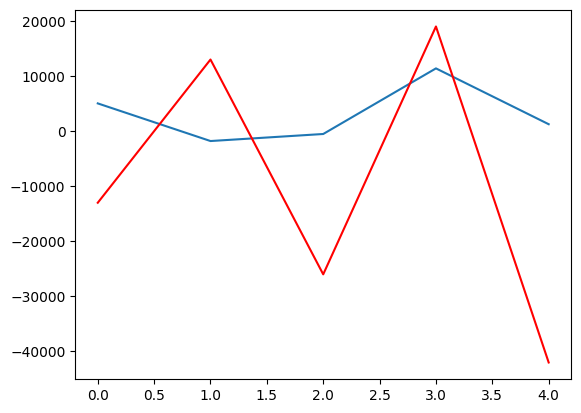

In [32]:
from matplotlib import pyplot
pyplot.plot(pred_diff)
pyplot.plot(test_diff,color='red')
print(pred_diff)

In [33]:
from math import sqrt
from sklearn.metrics import mean_squared_error
rmse = sqrt(mean_squared_error(test_diff, pred_diff))
print(rmse)

24990.18133457152


In [34]:
#prediksi 5 hari kedepan
pred_future_diff = model_diff.predict(start=len(gold_prices_diff), end=len(gold_prices_diff) + 4, dynamic=False)

In [35]:
# Mengembalikan prediksi masa depan ke skala asli
pred_future_original = pred_future_diff.cumsum() + gold_prices.iloc[-1]

print("Prediksi Masa Depan:")
print(pred_future_original)
print("Jumlah Prediksi Masa Depan:", len(pred_future_original))

Prediksi Masa Depan:
[2744764.65046198 2756770.45604339 2756089.94009367 2755844.88652395
 2762331.65937827]
Jumlah Prediksi Masa Depan: 5
